# Module 2: MS and MS/MS Annotation using Asari

Annotation of metabolomics data is often based on matching measured parameters to those of authentic compounds. This includes m/z, retention time in LC-MS or GC-MS, and fragmentation patterns in MS/MS. Additional parameters can be useful such as CCS from ion mobility spectrometry. 

This notebook illustrates the principles of LC-MS and MS/MS data annotation. For production analyses and advanced usage, please refer to Asari documentation. 


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shuzhao-li-lab/asari/blob/main/notebooks/NYC2026/Module_2_Asari_annotation.ipynb)

In [ ]:
# 0 - use pip to install asari if you haven't already
!pip3 install asari-metabolomics

In [ ]:
# 1 - library setup
import os
import json
import pandas as pd
import requests, zipfile, io

from datetime import date
from asari.tools.ms2 import extract_all_spectra_form_file
from asari.tools.file_io import read_features_from_asari_table
from asari.tools import match_features as mf

from asari.tools.cosine import cosine_similarity
from asari.tools.plot import mirror_plot
from asari.tools.msp_parser import MSP_dict, parse_msp_to_listdict, msp_standarize



In addition to the `MT02` dataset, we will use `Anno_data_202707.zip` from [https://github.com/shuzhao-li-lab/data/raw/main/data/Anno_data_202707.zip] .

This contains: 
- ID_01.mzML, a DDA file containing MS/MS spectra
- MSMS-Pos-MassBank.msp, a typical MS/MS database file	
- v3_authlib2024_hilicpos.json, a library of authentic compound from the Li lab

## Annotation using authentic compound library (MS1)

Here, we will annotate the feature table we created in Module 1 to our authentic standard library. 

### Data setup

If you're using this notebook on Google Colab, go ahead and use cell block 2A. 

If you're using this notebook on your own computer, use cell block 2B with the downloaded Anno_data_202707 (unzipped). Below, don't forget to update the paths to those on your own computer.

In [ ]:
# 2A - file path to feature table and authentic library for Colab only

from google.colab import drive

drive.mount("/content/drive")

# path to the feature table created in Module 1
ft_tbl = "/content/drive/MyDrive/NYC2026/preferred_Feature_table.tsv"

# now download and unzip the Anno_data folder
os.makedirs("./Datasets", exist_ok=True)

dataset = "https://github.com/shuzhao-li-lab/data/raw/main/data/Anno_data_202707.zip"

r = requests.get(dataset)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("./Datasets/")

annot_dir = "./Datasets/Anno_data/"

# path to the authentic compound library in the Anno_data_202707 unzipped
auth_lib_hilicpos = annot_dir + "v3_authlib2024_hilicpos.json"

In [ ]:
# 2B - file path to feature table and authentic library for your own computer

ft_tbl = os.path.expanduser(
    "~/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/results_asari_project_721155130/preferred_Feature_table.tsv"
)

annot_dir = "~/Downloads/Anno_data/"

auth_lib_hilicpos = os.path.expanduser(annot_dir + "v3_authlib2024_hilicpos.json")

Next we will read in the feature table, which parses the feature descriptors into a dictionary. This is similar to a named list in R, where you can index a list based on a position or name.

In [3]:
# 3 - read in feature table and convert to a list of dictionaries
num_samples, list_features = read_features_from_asari_table(open(ft_tbl).read())
len(list_features), list_features[0]

table header looks like: 
   ['id_number', 'mz', 'rtime', 'rtime_left_base', 'rtime_right_base', 'parent_masstrack_id', 'peak_area', 'cSelectivity', 'goodness_fitting', 'snr', 'detection_counts', 'batch14_MT_20210808_087', 'batch14_MT_20210808_179', 'batch14_MT_20210808_089', 'batch14_MT_20210808_181', 'batch12_MT_20210806_005', 'batch14_MT_20210808_005', 'batch11_MT_20210805_005', 'batch13_MT_20210807_005']
Read 5377 feature lines


(5377,
 {'id_number': 'F0',
  'id': 'F0',
  'mz': 83.0603,
  'rtime': 170.72,
  'apex': 170.72,
  'rtime_left_base': 168.8,
  'rtime_right_base': 175.35,
  'parent_masstrack_id': 0,
  'peak_area': 68325041.0,
  'cSelectivity': 1.0,
  'goodness_fitting': 0.89,
  'snr': 5.0,
  'detection_counts': 8})

Above, we see that there are ~5300 features, and an example of feature descriptors parsed from the table (first 11 columns). Now let's load the authentic compound library.

In [4]:
# 4 - # load authentic compound library
authLib = json.load(open(auth_lib_hilicpos))
len(authLib), authLib[0]

(760,
 {'id': 'v2r2024_pos_97.0735_HILIC_469.21',
  'mz': 97.0735,
  'rtime': 469.21,
  'ion': 'M+Na[1+]',
  'isotope': 'M0',
  'name': '1,3-Diaminopropane',
  'identifier': 'HMDB0000002',
  'HMDB': 'HMDB0000002',
  'PubChem': '',
  'method': 'MT8min',
  'formula': 'C3H10N2',
  'neutral_mass': 74.08439833125401})

In the code chunk above, there are 760 compounds in our authentic library, with an example of an entry in the output.

## Finding the best MS1 match

Using a m/z tolerance of 5ppm and a retention time window of 20 seconds, we will match our list of features to our authentic compound library.

In [5]:
# 5 - get matches between our feature table and authentic library
matches = mf.list_match_lcms_features(list_features, authLib, mz_ppm=5, rt_tolerance=20)
list(matches.items())[:3]

Of 5377 list1 features, number of uni-direction matched features is 55.


[('F87', ['v2r2024_pos_96.0444_HILIC_50.01']),
 ('F107', ['v2r2024_pos_100.0757_HILIC_41.92']),
 ('F117', ['v2r2024_pos_101.0791_HILIC_41.92'])]

In the output above, we can see that we have 55 features that have annotations to our authentic compound library, with the first three matches list above. However, we can see that the library matches are their IDs, without any compound names or other identifiers. We will next make dictionaries (named lists in R) mapping feature identifiers to the feature descriptors, and similarly the library identifiers to compound descriptors.

In [7]:
# 6 - make dictionaries
dict_f = {feature["id"]: feature for feature in list_features}
dict_lib = {feature["id"]: feature for feature in authLib}

print(dict(list(dict_f.items())[:1]))

{'F0': {'id_number': 'F0', 'id': 'F0', 'mz': 83.0603, 'rtime': 170.72, 'apex': 170.72, 'rtime_left_base': 168.8, 'rtime_right_base': 175.35, 'parent_masstrack_id': 0, 'peak_area': 68325041.0, 'cSelectivity': 1.0, 'goodness_fitting': 0.89, 'snr': 5.0, 'detection_counts': 8}}


Now that we have these dictionaries, let's look for the compound match for the first feature (F87).

In [10]:
# 7 - example match
print(
    f"Experimental feature:\n{dict_f['F87']}\n\n"
    f"Authentic compound library match:\n{dict_lib['v2r2024_pos_96.0444_HILIC_50.01']}"
)

Experimental feature:
{'id_number': 'F87', 'id': 'F87', 'mz': 96.0444, 'rtime': 32.55, 'apex': 32.55, 'rtime_left_base': 27.93, 'rtime_right_base': 37.17, 'parent_masstrack_id': 35, 'peak_area': 49264207.0, 'cSelectivity': 0.75, 'goodness_fitting': 0.97, 'snr': 40.0, 'detection_counts': 8}

Authentic compound library match:
{'id': 'v2r2024_pos_96.0444_HILIC_50.01', 'mz': 96.0444, 'rtime': 50.01, 'ion': 'M+H[1+]', 'isotope': 'M0', 'name': '2-Hydroxypyridine', 'identifier': 'HMDB0013751', 'HMDB': 'HMDB0013751', 'PubChem': '', 'method': 'MT8min', 'formula': 'C5H5NO', 'neutral_mass': 95.0371137851987}


Here, we can see F87 is likely 2-Hydroxypyridine. Ok, now let's join the dictionaries to make a nice table of results. Don't forget to update the path of ms1_output_dir to one on your own computer.

In [ ]:
# 8 - Write out mapped result to a tsv table and save output

ms1_output_dir = os.path.expanduser(annot_dir + "ms1_annotation/")
os.makedirs(ms1_output_dir, exist_ok=True)

tsv_path = os.path.join(
    ms1_output_dir,
    f"{date.today().strftime('%Y-%m-%d')}_authlib_ms1_annotations.tsv",
)

header = [
    "id",
    "mz",
    "rtime",
    "lib_id",
    "lib_name",
    "lib_mz",
    "lib_rtime",
    "lib_identifier",
]
s = "\t".join(header) + "\n"
for feature_id, matched_list in matches.items():
    for f2 in matched_list:
        s += (
            "\t".join(
                [
                    str(x)
                    for x in [
                        feature_id,
                        dict_f[feature_id]["mz"],
                        dict_f[feature_id]["rtime"],
                        f2,
                        dict_lib[f2]["name"],
                        dict_lib[f2]["mz"],
                        dict_lib[f2]["rtime"],
                        dict_lib[f2]["identifier"],
                    ]
                ]
            )
            + "\n"
        )

with open(tsv_path, "w") as f:
    f.write(s)

# save JSON output, which is more complete
json_path = tsv_path.replace(".tsv", ".json")

json_output = []
for feature_id, matched_list in matches.items():
    json_output.append(
        {
            feature_id: {
                "Feature": dict_f[feature_id],
                "Matched_libs": [dict_lib[lib_id] for lib_id in matched_list],
            }
        }
    )
with open(json_path, "w") as f:
    json.dump(json_output, f, indent=4)

Check the resulting tables out in the ms1_output_dir directory!

## MS/MS (MS2) Annotation

Above, we focused on annotating MS1 features derived from the feature table. In this next section, we will instead use MS2 data acquired using a data-dependent (DDA) workflow with Thermo AcquireX. As a result, each run contains both MS1 survey scans and MS2 fragmentation spectra from selected precursors. It is important to note that these samples are different from those used for Asari feature extraction and processing.

### Spectra databases

Several publicly available spectral databases can be used for MS2-based small molecule annotation. These include the MassBank of North America (MoNA, 2M spectra), Global Natural Products Social Molecular Networking (GNPS, community driven repository) and the Human Metabolome Database (HMDB). These resources include both experimentally acquired and computationally predicted (in-silico) MS2 spectra. Here, we will use the MS2 spectral database from MoNA. 

Make sure to update the file path to the one on your own computer.

In [ ]:
# 9 - load and look at a MoNA entry

massbank = msp_standarize(
    parse_msp_to_listdict(os.path.join(annot_dir, "MSMS-Pos-MassBank.msp")), MSP_dict
)

# show example
massbank[0]

{'NAME': 'Veratramine; LC-ESI-TOF; MS2; CE',
 'PRECURSORMZ': '410.305356',
 'PRECURSORTYPE': '[M+H]+',
 'FORMULA': 'C27H39NO2',
 'Ontology': 'Fluorenes',
 'INCHIKEY': 'MALFODICFSIXPO-KFKQDBFTSA-N',
 'SMILES': 'C[C@H]([C@@H]1NC[C@@H](C)C[C@H]1O)C1=C(C)C2=C(C=C1)[C@@H]1CC=C3C[C@@H](O)CC[C@]3(C)[C@H]1C2',
 'RETENTIONTIME': '',
 'CCS': '207.3842046',
 'IONMODE': 'Positive',
 'INSTRUMENTTYPE': 'LC-ESI-QTOF',
 'INSTRUMENT': '',
 'COLLISIONENERGY': '',
 'Comment': 'registered in MassBank',
 'Num Peaks': '83',
 'peaks': [(84.1, 32.0),
  (105.1, 6.0),
  (107.1, 6.0),
  (114.1, 105.0),
  (115.1, 7.0),
  (119.1, 8.0),
  (121.1, 6.0),
  (124.1, 83.0),
  (125.1, 8.0),
  (129.10001, 7.0),
  (131.10001, 129.0),
  (132.10001, 13.0),
  (133.10001, 212.0),
  (134.10001, 23.0),
  (144.10001, 5.0),
  (145.10001, 108.0),
  (146.10001, 12.0),
  (147.10001, 14.0),
  (151.10001, 8.0),
  (155.10001, 26.0),
  (156.10001, 17.0),
  (157.10001, 372.0),
  (158.10001, 45.0),
  (159.10001, 216.0),
  (160.10001, 29.0)

An example of an entry in the MoNA spectral database is shown above. Each entry contains key metadata about the referemce spectrum such as the precursor m/z, chemical formula, ionization mode, and collision energy used during its acquisition. The *peaks* array stores the MS2 fragmentation spectrum as pairs of fragment m/z values and corresponding intensities. These fragment ions are like a molecular fingerprint for a small molecule, and can be used to match experimental MS2 spectra against reference spectra for metabolite annotation.

In the code block below, we will parse the DDA mzML file and separate the MS1 and MS2 spectra into individual json files. Update the file path below to the location of MS2 .mzML files!

In [ ]:
# 10 - Read in the MS/MS file

[ms1_spectra, ms2_spectra, others] = extract_all_spectra_form_file(
    os.path.join(annot_dir, "ID_01.mzML")
)

with open(os.path.join(annot_dir, "ID_01_MS2.json"), "w") as O:
    json.dump(ms2_spectra, O)

term not found (MS:1000026)
term not found (MS:1000026)
term not found (MS:1000026)
term not found (MS:1000026)


Now we will load the created json file which contains the experimental MS2 spectra.

In [ ]:
# 11 - Read in the MS2 json
our_ms2 = json.load(open(os.path.join(annot_dir, "ID_01_MS2.json")))
our_ms2[0]

{'id': 'sp3',
 'precursor_mz': 214.987487792969,
 'rtime': 0.3385186399999998,
 'peaks': [[150.96871948242188, 162493],
  [72.93687438964844, 121631],
  [132.95811462402344, 108013],
  [191.9716033935547, 64118],
  [155.97413635253906, 57564],
  [173.9846954345703, 49743],
  [90.94745635986328, 49478],
  [113.96346282958984, 40465],
  [70.95758819580078, 24763],
  [197.0009002685547, 18890],
  [149.9607696533203, 13629],
  [209.98231506347656, 11765],
  [111.98410034179688, 8452],
  [55.9342041015625, 8411],
  [167.9715576171875, 7583],
  [91.90328979492188, 7071],
  [131.97401428222656, 7005],
  [154.99029541015625, 6903],
  [108.9580078125, 6778],
  [168.97915649414062, 6744],
  [172.97703552246094, 6354],
  [90.90292358398438, 6235],
  [132.9299774169922, 4377],
  [173.96128845214844, 4338],
  [149.94049072265625, 3264],
  [61.69279479980469, 2885],
  [72.5853500366211, 2741],
  [68.94639587402344, 2598],
  [87.19596862792969, 2478],
  [67.78878021240234, 2460],
  [72.06359100341797

For illustration purposes, we will calculate spectra similarity between our experimental spectra and MoNA spectra around 168 m/z. 

In [ ]:
# 12 - a subset of MS/MS database search

our_ms2_selected = [x for x in our_ms2 if int(x["precursor_mz"]) == 168]
db_ms2_selected = [x for x in massbank if int(float(x["PRECURSORMZ"])) == 168]
len(our_ms2_selected), len(db_ms2_selected)

(4, 5)

We have 4 experimental spectra and 5 database spectra at ~168 m/z. Let's calculate cosine similarity across these spectra to find good matches.

In [ ]:
# 13 - cosine similarity
# empty list to hold scores
cpd_ms2_scores = []

# for each experimental spectra
for x in our_ms2_selected:
    _scores = [
        round(
            float(cosine_similarity(x["peaks"], spec2["peaks"], mz_tolerance=0.01)[0]),
            3,
        )
        for spec2 in db_ms2_selected
    ]
    print(_scores)
    cpd_ms2_scores.append(_scores)


[0.0, 0.0, 0.0, 0.006, 0.989]
[0.0, 0.0, 0.0, 0.0, 0.961]
[0.0, 0.0, 0.0, 0.006, 0.824]
[0.0, 0.0, 0.0, 0.0, 0.856]


From the scores above (4 rows, 1 per experiemntal spectra) we can see that we have consistently high cosine similiarity scores from database spectra # 5. Remember, Python is 0-indexed, so we're looking at db_ms2_selected[4].

In [ ]:
# 14 - look at the top match
db_ms2_selected[4]

{'NAME': 'Pyridoxal; LC-ESI-QTOF; MS2; CE',
 'PRECURSORMZ': '168.06552',
 'PRECURSORTYPE': '[M+H]+',
 'FORMULA': 'C8H9NO3',
 'Ontology': 'Pyridoxals and derivatives',
 'INCHIKEY': 'RADKZDMFGJYCBB-UHFFFAOYSA-N',
 'SMILES': 'CC1=C(O)C(C=O)=C(CO)C=N1',
 'RETENTIONTIME': '',
 'CCS': '135.5965362',
 'IONMODE': 'Positive',
 'INSTRUMENTTYPE': 'LC-ESI-QTOF',
 'INSTRUMENT': '',
 'COLLISIONENERGY': '',
 'Comment': 'registered in MassBank',
 'Num Peaks': '6',
 'peaks': [(67.0546, 73.0),
  (94.0652, 225.0),
  (106.0655, 67.0),
  (122.0609, 136.0),
  (150.05431, 1000.0),
  (168.06599, 66.0)]}

Let's finish this up by looking at a mirror plot of the top match. 

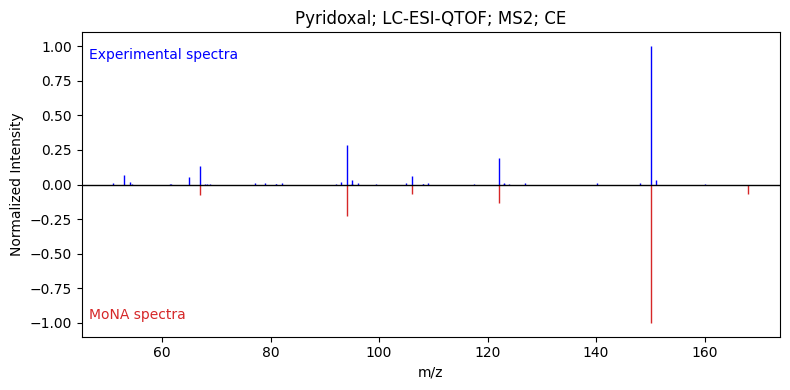

In [ ]:
# 15 - mirror plot of db_ms2_selected[4] best match to our_ms2_selected[0]

mirror_plot(
    our_ms2_selected[0]["peaks"],
    db_ms2_selected[4]["peaks"],
    label1="Experimental spectra",
    label2="MoNA spectra",
    title=db_ms2_selected[4]["NAME"],
    outfile=None,
)

# Summary

This notebook illustrates the principles of MS1 and MS2 annotation methods. 

For production-scale analyses, Asari provides methods to index and accelerate spectral matching. Please refer to Asari documentation for further details. 
